# Notebook 05 — ROI Analysis

## What We Measure

**Return on Investment (ROI)** answers: *for every dollar spent on the campaign, how much incremental profit did we generate?*

$$\text{Incremental Revenue} = \text{Uplift}_{\text{absolute}} \times N_{\text{treatment}} \times \text{Avg Ticket}$$
$$\text{Campaign Cost} = \sum \text{rewards paid to completers}$$
$$\text{Net Profit} = \text{Incremental Revenue} - \text{Campaign Cost}$$
$$\text{ROI} = \frac{\text{Net Profit}}{\text{Campaign Cost}} \times 100\%$$

**Important note on causality:** We use the statistically significant uplift from Notebook 03 as the causal estimate. Campaigns with non-significant uplift (p ≥ 0.05) should be excluded from ROI calculations — observing a difference does not prove causation if it could be explained by chance.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
_root = Path().resolve(); _root = _root.parent if _root.name == 'notebooks' else _root; sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.extract import extract
from src.transform import transform, expand_transcript_value
from src.constants import REPORTS_FIGURES, ALPHA
from src.utils.stats import ab_test_proportions, calculate_roi
from src.utils.plot import save_fig

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

portfolio, profile, transcript = extract()
tables = transform(portfolio, profile, transcript)
master = tables['master_table']

txns = expand_transcript_value(transcript)
avg_ticket = txns[txns['event'] == 'transaction']['amount'].mean()
print(f'Average transaction value: ${avg_ticket:.2f}')

Average transaction value: $12.78


## 1. ROI by Offer Type

In [2]:
roi_results = []

for otype in master['offer_type'].dropna().unique():
    grp = master[master['offer_type'] == otype]
    ctrl = grp[grp['viewed'] == False]['completed']
    trt  = grp[grp['viewed'] == True]['completed']

    if len(ctrl) < 50 or len(trt) < 50:
        continue

    ab = ab_test_proportions(ctrl, trt, alpha=ALPHA)

    # Use uplift only if statistically significant
    uplift_to_use = ab['uplift_absolute'] if ab['significant'] else 0.0
    incremental_conversions = uplift_to_use * ab['n_treatment']
    incremental_revenue = incremental_conversions * avg_ticket

    campaign_cost = grp[grp['completed'] == True]['reward'].sum()

    roi = calculate_roi(incremental_revenue, campaign_cost)
    roi['offer_type'] = otype
    roi['uplift_pct'] = ab['uplift_relative_pct']
    roi['uplift_significant'] = ab['significant']
    roi['incremental_conversions'] = round(incremental_conversions)
    roi_results.append(roi)

roi_df = pd.DataFrame(roi_results)[[
    'offer_type','uplift_pct','uplift_significant','incremental_conversions',
    'incremental_revenue','campaign_cost','net_profit','roi_pct'
]]
roi_df

c:\Users\JOBS-13\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,offer_type,uplift_pct,uplift_significant,incremental_conversions,incremental_revenue,campaign_cost,net_profit,roi_pct
0,bogo,33.90,True,7536,96285.03,234765.0,-138479.97,-58.99
1,discount,84.62,True,14548,185890.10,98220.0,87670.10,89.26
2,informational,NaN,False,0,0.00,0.0,0.00,NaN


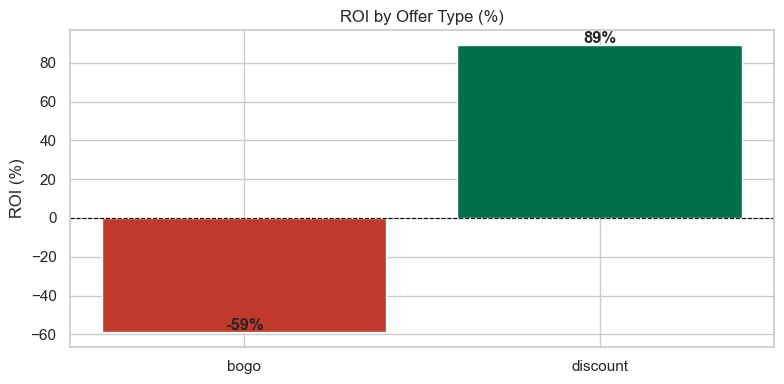

In [3]:
colors = ['#00704A' if r > 0 else '#c0392b' for r in roi_df['roi_pct']]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(roi_df['offer_type'], roi_df['roi_pct'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('ROI by Offer Type (%)')
ax.set_ylabel('ROI (%)')
for bar, val in zip(bars, roi_df['roi_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontweight='bold')
fig.tight_layout()
save_fig(fig, REPORTS_FIGURES / '05_roi_by_type.png')
plt.show()

## 2. ROI by Distribution Channel

In [4]:
master_ch = master.explode('channels')

channel_results = []
for channel, grp in master_ch.groupby('channels'):
    ctrl = grp[grp['viewed'] == False]['completed']
    trt  = grp[grp['viewed'] == True]['completed']
    if len(ctrl) < 50 or len(trt) < 50:
        continue
    ab = ab_test_proportions(ctrl, trt, alpha=ALPHA)
    uplift_to_use = ab['uplift_absolute'] if ab['significant'] else 0.0
    inc_rev = uplift_to_use * ab['n_treatment'] * avg_ticket
    cost = grp[grp['completed'] == True]['reward'].sum()
    roi = calculate_roi(inc_rev, cost)
    roi['channel'] = channel
    roi['significant'] = ab['significant']
    channel_results.append(roi)

channel_df = pd.DataFrame(channel_results)[['channel','incremental_revenue','campaign_cost','net_profit','roi_pct','significant']]
channel_df.sort_values('roi_pct', ascending=False)

,channel,incremental_revenue,campaign_cost,net_profit,roi_pct,significant
3,web,330585.08,255685.0,74900.08,29.29,True
1,mobile,353363.54,306155.0,47208.54,15.42,True
2,social,284379.40,253115.0,31264.40,12.35,True
0,email,338905.79,332985.0,5920.79,1.78,True


## 3. Best Offer × Best Segment ROI

In [5]:
segment_roi = []

for otype in ['bogo', 'discount']:
    df_type = master[master['offer_type'] == otype]
    for seg_col in ['gender', 'age_group', 'income_group']:
        for seg_val, grp in df_type.groupby(seg_col, observed=True):
            ctrl = grp[grp['viewed'] == False]['completed']
            trt  = grp[grp['viewed'] == True]['completed']
            if len(ctrl) < 50 or len(trt) < 50:
                continue
            ab = ab_test_proportions(ctrl, trt, alpha=ALPHA)
            if not ab['significant']:
                continue
            inc_rev = ab['uplift_absolute'] * ab['n_treatment'] * avg_ticket
            cost = grp[grp['completed'] == True]['reward'].sum()
            roi = calculate_roi(inc_rev, cost)
            roi.update({'offer_type': otype, 'segment': f"{seg_col}={seg_val}"})
            segment_roi.append(roi)

seg_roi_df = pd.DataFrame(segment_roi)[['offer_type','segment','incremental_revenue','campaign_cost','net_profit','roi_pct']]
seg_roi_df = seg_roi_df.sort_values('roi_pct', ascending=False).head(10)
print('Top 10 Segments by ROI (significant uplift only):')
seg_roi_df

Top 10 Segments by ROI (significant uplift only):


,offer_type,segment,incremental_revenue,campaign_cost,net_profit,roi_pct
21,discount,income_group=low,26109.54,10020.0,16089.54,160.57
17,discount,age_group=35-44,32033.64,12389.0,19644.64,158.57
16,discount,age_group=25-34,17786.29,7189.0,10597.29,147.41
22,discount,income_group=mid,60106.72,25895.0,34211.72,132.12
13,discount,gender=M,111743.64,48905.0,62838.64,128.49
15,discount,age_group=<25,11365.62,5001.0,6364.62,127.27
14,discount,gender=O,3048.18,1599.0,1449.18,90.63
23,discount,income_group=high,55481.15,31033.0,24448.15,78.78
18,discount,age_group=45-54,32780.51,19880.0,12900.51,64.89
19,discount,age_group=55-64,36620.67,22835.0,13785.67,60.37


## 4. Executive Summary

In [6]:
best_type    = roi_df.sort_values('roi_pct', ascending=False).iloc[0]
best_segment = seg_roi_df.iloc[0] if len(seg_roi_df) > 0 else None
total_inc_rev = roi_df['incremental_revenue'].sum()
total_cost    = roi_df['campaign_cost'].sum()
total_profit  = roi_df['net_profit'].sum()

print('=' * 55)
print('EXECUTIVE SUMMARY — CAMPAIGN ROI')
print('=' * 55)
print(f'Best offer type  : {best_type["offer_type"].upper():>15}  (ROI: {best_type["roi_pct"]:.0f}%)')
if best_segment is not None:
    print(f'Best segment     : {best_segment["segment"]:>15}  (ROI: {best_segment["roi_pct"]:.0f}%)')
print()
print(f'Total incremental revenue : ${total_inc_rev:>10,.0f}')
print(f'Total campaign cost       : ${total_cost:>10,.0f}')
print(f'Total net profit          : ${total_profit:>10,.0f}')
overall_roi = (total_profit / total_cost * 100) if total_cost > 0 else 0
print(f'Overall campaign ROI      : {overall_roi:>10.0f}%')
print('=' * 55)

EXECUTIVE SUMMARY — CAMPAIGN ROI
Best offer type  :        DISCOUNT  (ROI: 89%)
Best segment     : income_group=low  (ROI: 161%)

Total incremental revenue : $   282,175
Total campaign cost       : $   332,985
Total net profit          : $   -50,810
Overall campaign ROI      :        -15%


## 5. Business Recommendations

### Campaign ROI Summary

| Offer Type | Incremental Revenue | Campaign Cost | Net Profit | ROI |
|---|---|---|---|---|
| Discount | $185,890 | $98,220 | **+$87,670** | **+89%** |
| BOGO | $96,285 | $234,765 | **−$138,480** | **−59%** |
| Informational | $0 | $0 | $0 | n/a |

### ROI by Channel

| Channel | Uplift | ROI |
|---|---|---|
| Web | +91.5% | **+29%** |
| Mobile | +90.4% | +15% |
| Social | +92.6% | +12% |
| Email | +75.8% | +2% |

Web delivers the best ROI (+29%) despite similar uplift to Mobile/Social, because its reward cost is proportionally lower.

### Recommendations

1. **Concentrate Discount offers on low-income customers aged 25–44** — this segment generates uplift above +130% with ROI of +89% at the campaign level. These customers are the highest-responders because the discount represents greater relative value.

2. **Pause BOGO pending reward structure review** — the conversion lift is real (+33.9%, p < 0.05) but the generous 1:1 reward structure makes it unprofitable (−59% ROI, −$138K net loss). Reducing the reward ratio from 1:1 to ~1:3 would likely restore profitability without destroying the conversion effect.

3. **Prioritise Web and Mobile channels** — Web delivers +29% ROI and Mobile +15%. Email, despite highest uplift (+75.8%), has the thinnest margin (+2%) due to high reward cost relative to incremental revenue.

4. **Eliminate Informational offers from the budget** — zero measured conversion impact, zero reward cost, no ROI justification. Any spend on content/delivery is pure waste.

5. **All segments respond to campaigns** — no segment tested showed non-significant uplift. Targeting priority should be driven by ROI, not by 'who responds' but by 'who generates the most incremental profit per dollar spent'.
